In [1]:
import kagglehub
from pathlib import Path
import pandas as pd
import re


/home/guillaume/Workspace/ohw/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the data

In [2]:
data_dir = Path("./data")
data_dir.mkdir(exist_ok=True)

path = kagglehub.dataset_download(
    "ludmin/billboard",
    output_dir=str(data_dir)
)

In [3]:
hot100 = pd.read_csv('data/hot100.csv')

### Dropping useless columns

In [4]:
hot100 = hot100.drop(columns=['Last Week', 'Peak Position', 'Weeks in Charts'])

In [5]:
hot100

,Date,Song,Artist,Rank,Image URL
0,1958-07-30,Poor Little Fool,Ricky Nelson,1,NaN
1,1958-07-30,Patricia,Perez Prado And His Orchestra,2,NaN
2,1958-07-30,Splish Splash,Bobby Darin,3,NaN
3,1958-07-30,Hard Headed Woman,Elvis Presley With The Jordanaires,4,https://charts-static.billboard.com/img/1958/0...
4,1958-07-30,When,Kalin Twins,5,NaN
...,...,...,...,...,...
355353,2026-09-02,Rubberz,Fenix Flexin,96,https://charts-static.billboard.com/img/2026/0...
355354,2026-09-02,Bet On That,Blake Whiten,97,https://charts-static.billboard.com/img/2025/0...
355355,2026-09-02,Ran To Atlanta,Drake Featuring Future & Molly Santana,98,https://charts-static.billboard.com/img/2009/0...
355356,2026-09-02,National Treasures,Drake,99,https://charts-static.billboard.com/img/2009/0...


In [6]:
hot100.isnull().mean().sort_values(ascending=False)

Image URL    0.349549
Date         0.000000
Song         0.000000
Artist       0.000000
Rank         0.000000
dtype: float64

In [7]:
hot100.shape

(355358, 5)

### Dropping songs higher than top 40

In [8]:
hot100 = hot100[hot100["Rank"] <= 40].reset_index(drop=True)

In [9]:
hot100.shape

(142137, 5)

### creating new columns

In [10]:
hot100["WeeksTop40"] = hot100.groupby(["Song", "Artist"])["Song"].transform("count")

In [11]:
#TODO: change the artist group to remove the feat


def extract_main_artist(artist_str: str) -> str:
    # Remove common featuring / with / vs patterns and keep the first main artist
    # Examples: "A feat. B", "A featuring B", "A with B", "A vs B", "A & B"
    # We'll treat the first name before these keywords as the main artist.

    # Split on common separators and take the first part
    parts = re.split(r"\s+(?:feat\.?|featuring|with|vs\.?|&|and)\s+", str(artist_str), flags=re.IGNORECASE)
    main = parts[0].strip()

    # Optionally clean trailing punctuation or extra spaces
    main = re.sub(r"\s+[,;&]\s*$", "", main).strip()
    return main

hot100["MainArtist"] = hot100["Artist"].apply(extract_main_artist)

artist_song_counts = hot100.groupby("MainArtist")["Song"].nunique()
hot100["OneHitWonder"] = hot100["MainArtist"].map(artist_song_counts == 1)


In [12]:
hot100 = hot100[hot100["OneHitWonder"] ==  True].reset_index(drop=True)

In [13]:
hot100

,Date,Song,Artist,Rank,Image URL,WeeksTop40,MainArtist,OneHitWonder
0,1958-07-30,Patricia,Perez Prado And His Orchestra,2,NaN,11,Perez Prado,True
1,1958-07-30,Willie And The Hand Jive,The Johnny Otis Show,9,NaN,6,The Johnny Otis Show,True
2,1958-07-30,One Summer Night,The Danleers,16,NaN,6,The Danleers,True
3,1958-07-30,Endless Sleep,Jody Reynolds,17,NaN,3,Jody Reynolds,True
4,1958-07-30,Little Star,The Elegants,18,NaN,15,The Elegants,True
...,...,...,...,...,...,...,...,...
22652,2026-09-02,Islands In The Stream,Kenny Rogers Duet With Dolly Parton,26,https://charts-static.billboard.com/img/1983/0...,19,Kenny Rogers Duet,True
22653,2026-09-02,Dai Dai (FIFA World Cup Official Song 2026),Shakira X Burna Boy,32,https://charts-static.billboard.com/img/2026/0...,6,Shakira X Burna Boy,True
22654,2026-09-02,Spend Dat,Yung Miami,34,https://charts-static.billboard.com/img/2026/0...,12,Yung Miami,True
22655,2026-09-02,What You Need,Tems,37,https://charts-static.billboard.com/img/2025/1...,7,Tems,True


In [14]:
hot100["Date"] = pd.to_datetime(hot100["Date"], format="%Y-%m-%d")

# Year and decade
hot100["Year"] = hot100["Date"].dt.year
hot100["Decade"] = (hot100["Year"] // 10) * 10

# One-hit-wonder flag: artist with only one distinct song in the dataset
artist_song_counts = hot100.groupby("Artist")["Song"].nunique()
hot100["OneHitWonder"] = hot100["Artist"].map(artist_song_counts == 1)

In [15]:
yearly_ohw = (
    hot100[hot100["OneHitWonder"]]
    .groupby("Year")["Artist"]
    .nunique()
    .reset_index(name="one_hit_wonder_artists")
)

# Optional: total distinct artists per year
yearly_all = (
    hot100
    .groupby("Year")["Artist"]
    .nunique()
    .reset_index(name="total_artists")
)

yearly = yearly_all.merge(yearly_ohw, on="Year", how="left").fillna(0)

In [16]:
decade_ohw = (
    hot100[hot100["OneHitWonder"]]
    .groupby("Decade")["Artist"]
    .nunique()
    .reset_index(name="one_hit_wonder_artists")
)

decade_all = (
    hot100
    .groupby("Decade")["Artist"]
    .nunique()
    .reset_index(name="total_artists")
)

decade = decade_all.merge(decade_ohw, on="Decade", how="left").fillna(0)

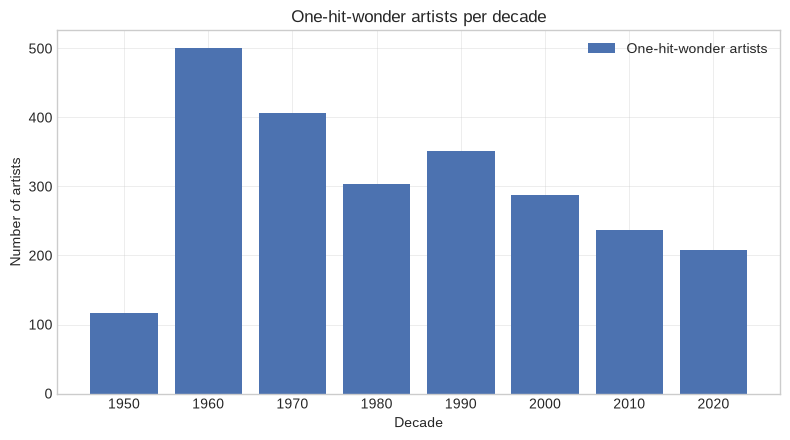

In [17]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    decade["Decade"].astype(str),
    decade["one_hit_wonder_artists"],
    color="#4c72b0",
    label="One-hit-wonder artists"
)

ax.set_xlabel("Decade")
ax.set_ylabel("Number of artists")
ax.set_title("One-hit-wonder artists per decade")
ax.legend()

plt.tight_layout()
plt.show()